Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Размерность данных после кодирования: (45211, 46)
Объясненная дисперсия 2 компонентами: 34.03%


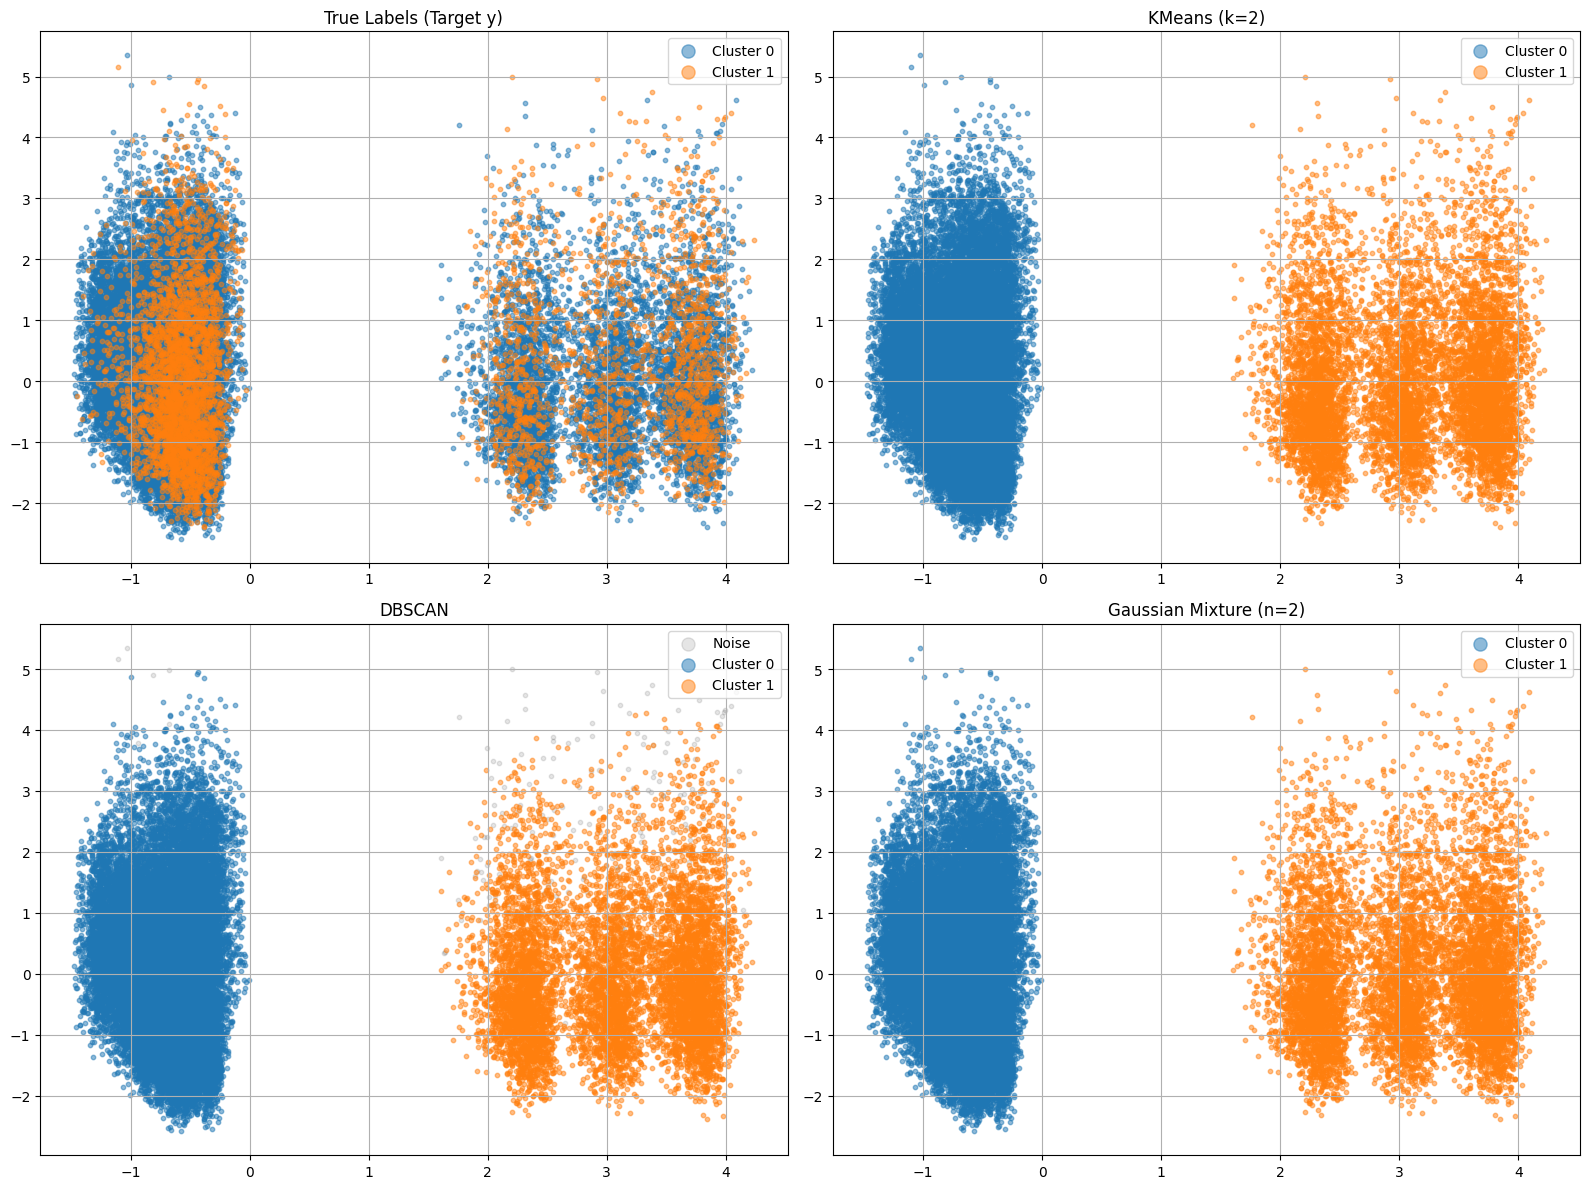


Сравнение с истинными метками (y)
Method     | ARI (Rand Index)     | NMI (Mutual Info)   
--------------------------------------------------------
KMeans     | 0.1148               | 0.0287
DBSCAN     | 0.1166               | 0.0286
GMM        | 0.1148               | 0.0287


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

path = kagglehub.dataset_download("adityamhaske/bank-marketing-dataset") + "/bank-full.csv"
data_raw = pd.read_csv(path, delimiter=';')

df = data_raw.copy()

df['pdays_contacted'] = np.where(df['pdays'] == -1, 0, 1)
df.drop(columns=['pdays'], inplace=True)

df.drop(columns=['default', 'duration'], inplace=True)

features_to_check = ['balance', 'campaign', 'previous']
for col in features_to_check:
    lower_percentile = df[col].quantile(0.05)
    upper_percentile = df[col].quantile(0.95)

    df[col] = np.where(df[col] > upper_percentile, upper_percentile, df[col])
    df[col] = np.where(df[col] < lower_percentile, lower_percentile, df[col])

y_true = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), categorical_cols)
    ]
)

X_scaled = preprocessor.fit_transform(X)

if hasattr(X_scaled, "toarray"):
    X_scaled = X_scaled.toarray()

print(f"Размерность данных после кодирования: {X_scaled.shape}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Объясненная дисперсия 2 компонентами: {pca.explained_variance_ratio_.sum():.2%}")

predictions = {}

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
predictions['KMeans'] = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=2.5, min_samples=20)
predictions['DBSCAN'] = dbscan.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=2, random_state=42)
predictions['GMM'] = gmm.fit_predict(X_scaled)

def plot_clusters(X_2d, labels, title, ax):
    unique_labels = np.unique(labels)
    for lbl in unique_labels:
        # Для DBSCAN шум обозначается -1
        if lbl == -1:
            color = 'black'
            label_name = 'Noise'
            alpha = 0.1
        else:
            color = None
            label_name = f'Cluster {lbl}'
            alpha = 0.5

        mask = (labels == lbl)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label_name, s=10, alpha=alpha, c=color)

    ax.grid()
    ax.set_title(title)
    ax.legend(markerscale=3, loc='upper right')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_clusters(X_pca, y_true, "True Labels (Target y)", axes[0, 0])
plot_clusters(X_pca, predictions['KMeans'], "KMeans (k=2)", axes[0, 1])
plot_clusters(X_pca, predictions['DBSCAN'], "DBSCAN", axes[1, 0])
plot_clusters(X_pca, predictions['GMM'], "Gaussian Mixture (n=2)", axes[1, 1])

plt.tight_layout()
plt.show()

print("\nСравнение с истинными метками (y)")
print(f"{'Method':<10} | {'ARI (Rand Index)':<20} | {'NMI (Mutual Info)':<20}")
print("-" * 56)

for name, preds in predictions.items():
    ari = adjusted_rand_score(y_true, preds)
    nmi = normalized_mutual_info_score(y_true, preds)
    print(f"{name:<10} | {ari:.4f}{' '*14} | {nmi:.4f}")

Перед применением алгоритмов кластеризации данные были подвергнуты кодированию (OneHotEncoding для категориальных признаков) и стандартизации (StandardScaler). Стандартизация необходима, ведь методы кластеризации основаны на измерении расстояния между точками.

Мы используем метод PCA (главных компонент) для сжатия данных до двух измерений, что позволяет построить графики, сохранив большую часть информации. Конечно, две компоненты объясняют лишь часть дисперсии, поэтому мы видим лишь упрощённую проекцию.

Были применены три различных подхода к кластеризации, чтобы проверить гипотезу о наличии естественных групп в данных:

1.   K-Means (Метод k-средних): пытается разделить данные на k групп (в нашем случае k=2, чтобы сопоставить с бинарной целевой переменной), минимизируя расстояние от точек до центра их кластера;
2.   DBSCAN (Density-Based Spatial Clustering of Applications with Noise): алгоритм, основанный на плотности точек. Он объединяет близко расположенные точки в кластеры и помечает разреженные области как шум;
3.   Gaussian Mixture Models (GMM, Смесь гауссовых распределений): вероятностная модель, которая предполагает, что данные сгенерированы смесью нескольких нормальных распределений (эллипсов). По сути, это более гибкий вариант метода k-means.

Поскольку в данных у нас есть истинные метки классов (y — оформил депозит или нет), мы можем сравнить результат кластеризации с реальностью, используя внешние метрики:

1.   ARI (Adjusted Rand Index): измеряет сходство между двумя разбиениями данных. Значение 1 - полное совпадение разбиений, 0 - совпадение случайное;
2.   NMI (Normalized Mutual Information): показывает количество общей информации между результатом кластеризации и истинными метками. Т.е. зная номер кластера, насколько точно получается предсказывать истинный класс.

Визуализация показала, что истинные классы сильно смешаны в пространстве признаков и не образуют геометрически изолированных групп. Метрики ARI и NMI для всех трех алгоритмов оказались близкими к нулю. Алгоритмы разделили данные на основе геометрической близости (например, отделили одну группу признаков от другой), но это разделение никак не коррелирует с тем, оформит клиент депозит или нет.

Кажется, это связано с особенностями набора данных, ведь алгоритмы сгруппировали похожих клиентов (по возрасту, достатку и прочему), а их решения зависят от сложной комбинации факторов, которая не проявляется в виде "островов" в данных.

Таким образом, применение методов кластеризации для задачи предсказания оттока или отклика неэффективно. Эти данные не обладают кластерной структурой, совпадающей с целевой переменной. Для решения задачи необходимо использовать методы обучения с учителем, которые способны находить сложные нелинейные зависимости, а не просто группировать точки по расстоянию, что и было продемонстрировано в предыдущей работе.


